# Train prediction models (warehouse / synthetic data)

This notebook trains the same models the API loads from `backend/models/`:

- **`MultiModelPredictor`** → `multi_model_predictor.pkl` (random forest, gradient boosting, neural net + ensemble used by `/api/predictions/predict`)
- **`EnhancedPredictor`** → `enhanced_predictor.pkl` (tuition + attendance → grade, enrollment trends, etc.)

Data is read from the PostgreSQL **data warehouse** (`ucu_datawarehouse` by default), typically populated from **synthetic** CSVs via your ETL pipeline.

**Prerequisites:** Warehouse is loaded; `PG_HOST`, `PG_PORT`, `PG_USER`, `PG_PASSWORD` (or `DATABASE_URL`) match `backend/config.py`.

### Run inside the backend Docker container (recommended)

The backend image sets `WORKDIR` and **`APP_ROOT=/app`** so imports resolve the same as the API.

1. Rebuild so Jupyter is installed: `docker compose build backend-jupyter` (or `docker compose build backend`).
2. Start Postgres + Jupyter: `docker compose --profile notebooks up -d postgres backend-jupyter`
3. Open **http://localhost:8888/lab?token=dev** and open `notebooks/train_prediction_models_synthetic.ipynb`.

`PG_HOST=postgres` is already set in Compose, so the warehouse check cell talks to the same DB as `nextgen_backend`.

**After training:** restart the API container so it reloads pickles: `docker compose restart backend`.

### Run on your host (optional)

Use a venv with `backend/requirements.txt` installed, then run Jupyter from repo root, `backend/`, or `backend/notebooks/` (the next cell finds `ml_models.py`).

In [1]:
import os
import sys
from pathlib import Path

# Resolve backend root (contains ml_models.py). Docker backend image: /app with APP_ROOT=/app.
_env_root = os.environ.get("APP_ROOT", "").strip()
candidates = []
if _env_root:
    candidates.append(Path(_env_root))
candidates.extend(
    [
        Path("/app"),  # backend Dockerfile WORKDIR
        Path.cwd(),
        Path.cwd() / "backend",
        Path.cwd().parent,
        Path.cwd().parent / "backend",
    ]
)
BACKEND = None
for c in candidates:
    c = Path(c).resolve()
    if (c / "ml_models.py").is_file():
        BACKEND = c
        break
if BACKEND is None:
    raise FileNotFoundError(
        "Could not find backend (ml_models.py). In Docker use the backend image; "
        "on the host, start Jupyter from repo root, backend/, or backend/notebooks/."
    )

os.chdir(BACKEND)
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

print("BACKEND =", BACKEND)

BACKEND = /app


In [2]:
from sqlalchemy import create_engine, text
from config import DATA_WAREHOUSE_CONN_STRING, DATA_WAREHOUSE_NAME

engine = create_engine(DATA_WAREHOUSE_CONN_STRING)
with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM dim_student")).scalar()
print(f"Connected to warehouse \"{DATA_WAREHOUSE_NAME}\": dim_student rows = {n}")
engine.dispose()

Connected to warehouse "ucu_datawarehouse": dim_student rows = 10000


## 1. Standard multi-model performance predictor

Writes `backend/models/multi_model_predictor.pkl`.

In [3]:
from ml_models import MultiModelPredictor
import pandas as pd

standard = MultiModelPredictor()
standard_results = standard.train_all_models(use_grid_search=False)

# Flatten nested metrics dict into a table
# Columns expected: r2, rmse, mae.
df = pd.DataFrame.from_dict(standard_results, orient='index')

df = df.round(4)
df = df.sort_values(by='r2', ascending=False)

df

Preparing features...

Training Random Forest...
Random Forest - R²: 0.9435, RMSE: 1.26

Training Gradient Boosting...
Gradient Boosting - R²: 0.9353, RMSE: 1.35


,r2,rmse,mae
ensemble,0.9458,1.2373,0.9268
random_forest,0.9435,1.2627,0.9210
gradient_boosting,0.9353,1.3510,1.0141


In [4]:
# Enhanced training may fail partially if Postgres restarts mid-run.
# Keep going and still generate charts for anything that succeeded.
from pathlib import Path

# Verify expected model artifacts are present
MODELS_DIR = Path('models')
expected = [
    'multi_model_predictor.pkl',
    'enhanced_predictor.pkl',
]

present = {f: (MODELS_DIR / f).exists() for f in expected}
print('Models saved in backend/models:')
for f, ok in present.items():
    print(f' - {f}: {"OK" if ok else "MISSING"}')

missing = [f for f, ok in present.items() if not ok]
if missing:
    print("WARNING: Missing model artifacts:", missing)
else:
    print("All expected model artifacts are present.")

# Build a combined metrics table (regression metrics + classification metrics where available)
import pandas as pd

std_df = pd.DataFrame.from_dict(globals().get('standard_results', {}), orient='index')
std_df = std_df.reset_index().rename(columns={'index': 'model'})

enh_df = pd.DataFrame(columns=['model', 'metric', 'value'])
if 'enhanced_results' in globals() and isinstance(enhanced_results, dict):
    rows = []
    for model_name, metrics in enhanced_results.items():
        if not isinstance(metrics, dict):
            continue
        for k, v in metrics.items():
            rows.append({'model': model_name, 'metric': k, 'value': v})
    enh_df = pd.DataFrame(rows)

print('\nStandard models metrics (head):')
display(std_df.head())
print('\nEnhanced models metrics (head):')
display(enh_df.head())


Models saved in backend/models:
 - multi_model_predictor.pkl: OK
 - enhanced_predictor.pkl: OK
All expected model artifacts are present.

Standard models metrics (head):


,model,r2,rmse,mae
0,random_forest,0.943511,1.262698,0.921002
1,gradient_boosting,0.935332,1.351017,1.014144
2,ensemble,0.945760,1.237297,0.926762



Enhanced models metrics (head):


,model,metric,value


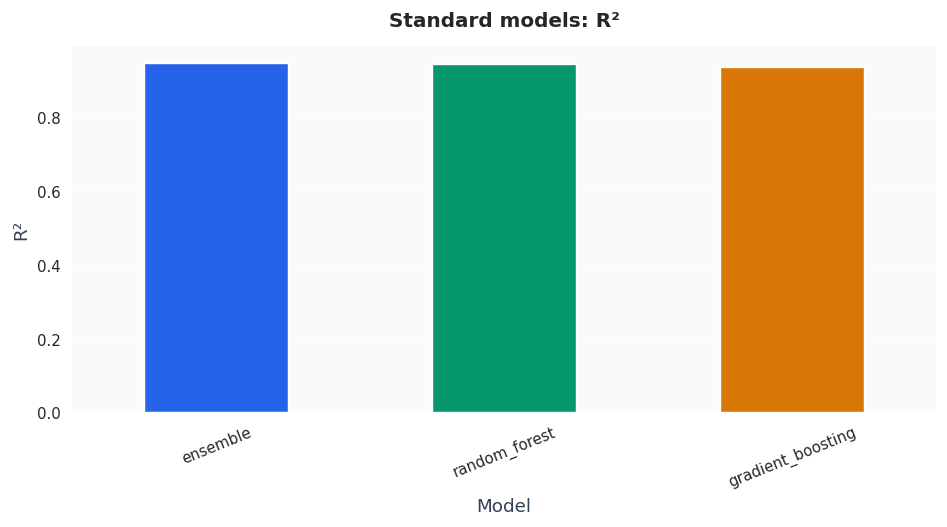

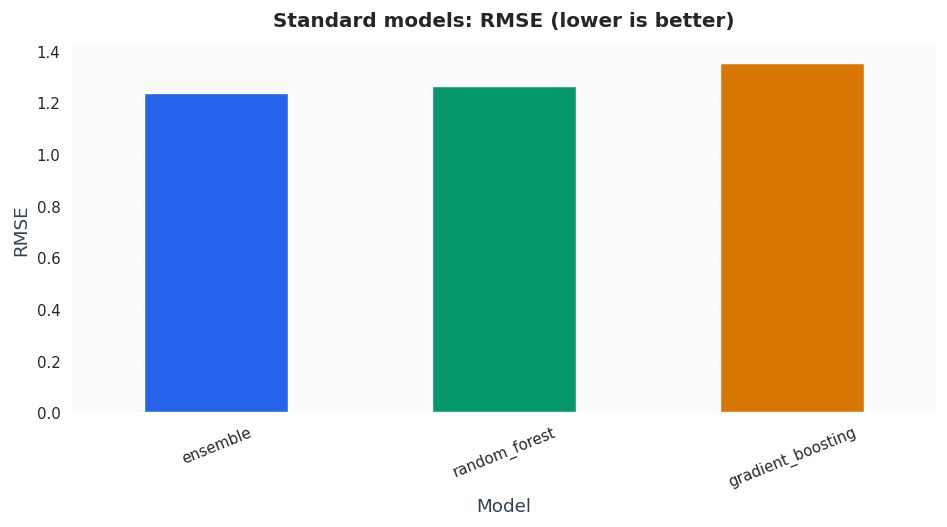

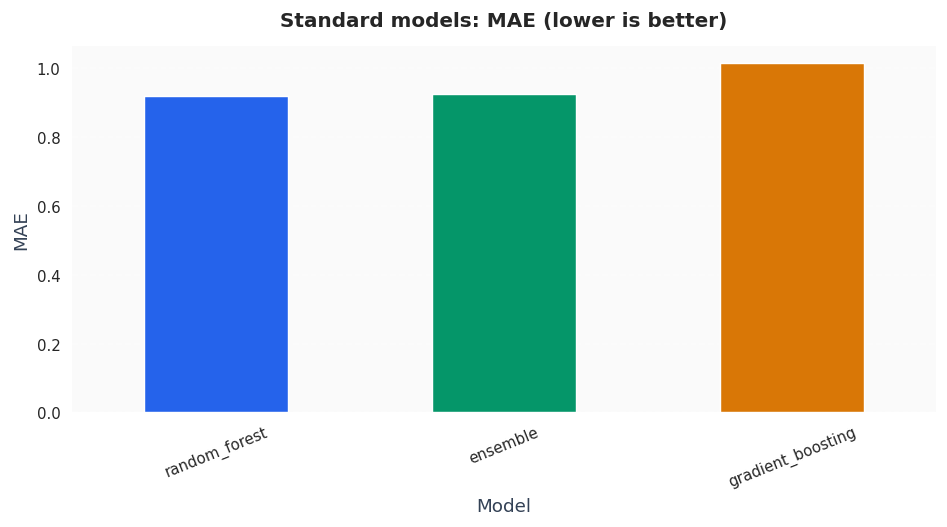

\nNo enhanced_results metrics to chart (enhanced training may have failed earlier).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cbd5e1',
    'axes.labelcolor': '#334155',
    'axes.titleweight': '600',
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'sans-serif',
})

CHART_BAR_COLORS = [
    '#2563eb', '#059669', '#d97706', '#7c3aed', '#0891b2',
    '#4f46e5', '#0d9488', '#6366f1', '#ca8a04', '#0284c7',
]


def _bar_colors(n):
    return [CHART_BAR_COLORS[i % len(CHART_BAR_COLORS)] for i in range(n)]


def _finish_bar_chart(ax, title, ylabel, xlabel='Model'):
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis='x', rotation=22)
    ax.yaxis.grid(True, linestyle='--', alpha=0.35)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('#cbd5e1')
    ax.spines['left'].set_color('#cbd5e1')
    plt.tight_layout()


def _plot_sorted_bars(series, title, ylabel, ascending):
    s = series.sort_values(ascending=ascending)
    ax = s.plot(
        kind='bar',
        figsize=(8, 4.5),
        color=_bar_colors(len(s)),
        edgecolor='white',
        linewidth=0.85,
    )
    _finish_bar_chart(ax, title, ylabel)
    plt.show()


# ---------- Standard models charts (MultiModelPredictor) ----------
std_df = pd.DataFrame.from_dict(globals().get('standard_results', {}), orient='index')

reg_metrics = ['r2', 'rmse', 'mae']
reg_df = std_df[[c for c in reg_metrics if c in std_df.columns]].copy()
if not reg_df.empty:
    if 'r2' in reg_df.columns:
        _plot_sorted_bars(reg_df['r2'], 'Standard models: R\u00b2', 'R\u00b2', ascending=False)
    if 'rmse' in reg_df.columns:
        _plot_sorted_bars(reg_df['rmse'], 'Standard models: RMSE (lower is better)', 'RMSE', ascending=True)
    if 'mae' in reg_df.columns:
        _plot_sorted_bars(reg_df['mae'], 'Standard models: MAE (lower is better)', 'MAE', ascending=True)

# ---------- Enhanced models charts (EnhancedPredictor) ----------
enhanced_rows = []
if 'enhanced_results' in globals() and isinstance(enhanced_results, dict):
    for model_name, metrics in enhanced_results.items():
        if isinstance(metrics, dict):
            for k, v in metrics.items():
                enhanced_rows.append((model_name, k, v))

if enhanced_rows:
    enh_table = pd.DataFrame(enhanced_rows, columns=['model', 'metric', 'value'])
    print('\\nEnhanced metrics table:')
    display(enh_table.sort_values(['model', 'metric']))

    for m in ['r2', 'rmse']:
        subset = enh_table[enh_table['metric'] == m]
        if not subset.empty:
            pivot = subset.set_index('model')['value']
            _plot_sorted_bars(
                pivot,
                f'Enhanced models: {m}',
                m,
                ascending=(m == 'rmse'),
            )

else:
    print('\\nNo enhanced_results metrics to chart (enhanced training may have failed earlier).')


## 2. Enhanced models (tuition + attendance, enrollment, …)

Writes `backend/models/enhanced_predictor.pkl`.

In [6]:
from enhanced_predictions import EnhancedPredictor

enhanced = EnhancedPredictor()
enhanced_results = enhanced.train_all_models()
enhanced_results

TRAINING ALL ENHANCED PREDICTION MODELS
  • Tuition + attendance → grade … OK
  • Enrollment trend … OK
  • Foundational course … OK
  • HR employment … OK
All models saved successfully!

--- Summary (all enhanced blocks) ---
                       model status metric   value
Tuition + attendance → grade     OK     r2 -0.0579
Tuition + attendance → grade     OK   rmse  4.3791
            Enrollment trend     OK     r2  0.9975
            Enrollment trend     OK   rmse  0.1554
         Foundational course     OK     r2  1.0000
         Foundational course     OK   rmse  0.0000
         Foundational course     OK    mae  0.0000
               HR employment     OK     r2 -0.0667
               HR employment     OK   rmse  0.4472
               HR employment     OK    mae  0.2000
TRAINING COMPLETE


{'tuition_attendance': {'r2': -0.05794898384827385, 'rmse': 4.379112060363899},
 'enrollment_trend': {'r2': 0.9975437713560783, 'rmse': 0.15535360822891617},
 'foundational_course': {'r2': 1.0, 'rmse': 0.0, 'mae': 0.0},
 'hr': {'r2': -0.06666666666666665, 'rmse': 0.4472135954999579, 'mae': 0.2}}

In [7]:
# Post-training verification + metrics summary (run after enhanced.train_all_models())
from pathlib import Path
import pandas as pd

MODELS_DIR = Path('models')
expected = ['multi_model_predictor.pkl', 'enhanced_predictor.pkl']

present = {f: (MODELS_DIR / f).exists() for f in expected}
print('Models saved in backend/models:')
for f, ok in present.items():
    print(f' - {f}: {"OK" if ok else "MISSING"}')

missing = [f for f, ok in present.items() if not ok]
if missing:
    print('WARNING: missing artifacts:', missing)
else:
    print('All expected model artifacts are present.')

# Metrics tables
std_df = pd.DataFrame.from_dict(globals().get('standard_results', {}), orient='index').reset_index().rename(columns={'index': 'model'})
print('\nStandard models metrics:')
display(std_df.round(4))

enh_table = pd.DataFrame(columns=['model', 'metric', 'value'])
if 'enhanced_results' in globals() and isinstance(enhanced_results, dict):
    rows = []
    for model_name, metrics in enhanced_results.items():
        if isinstance(metrics, dict):
            for k, v in metrics.items():
                rows.append({'model': model_name, 'metric': k, 'value': v})
    enh_table = pd.DataFrame(rows)

print('\nEnhanced models metrics:')
if enh_table.empty:
    print('No enhanced metrics available (enhanced training may have failed earlier).')
else:
    display(enh_table.sort_values(['model', 'metric']))


Models saved in backend/models:
 - multi_model_predictor.pkl: OK
 - enhanced_predictor.pkl: OK
All expected model artifacts are present.

Standard models metrics:


,model,r2,rmse,mae
0,random_forest,0.9435,1.2627,0.9210
1,gradient_boosting,0.9353,1.3510,1.0141
2,ensemble,0.9458,1.2373,0.9268



Enhanced models metrics:


,model,metric,value
2,enrollment_trend,r2,0.997544
3,enrollment_trend,rmse,0.155354
6,foundational_course,mae,0.000000
4,foundational_course,r2,1.000000
5,foundational_course,rmse,0.000000
9,hr,mae,0.200000
7,hr,r2,-0.066667
8,hr,rmse,0.447214
0,tuition_attendance,r2,-0.057949
1,tuition_attendance,rmse,4.379112


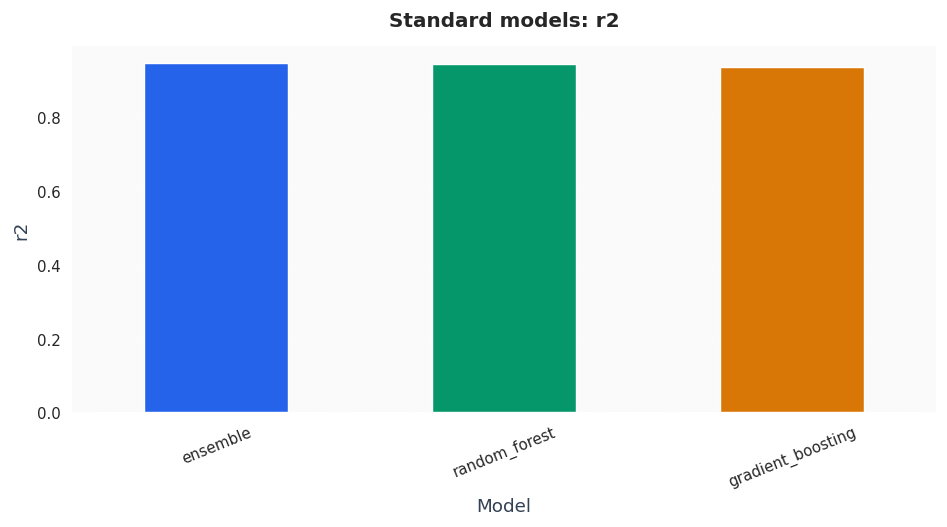

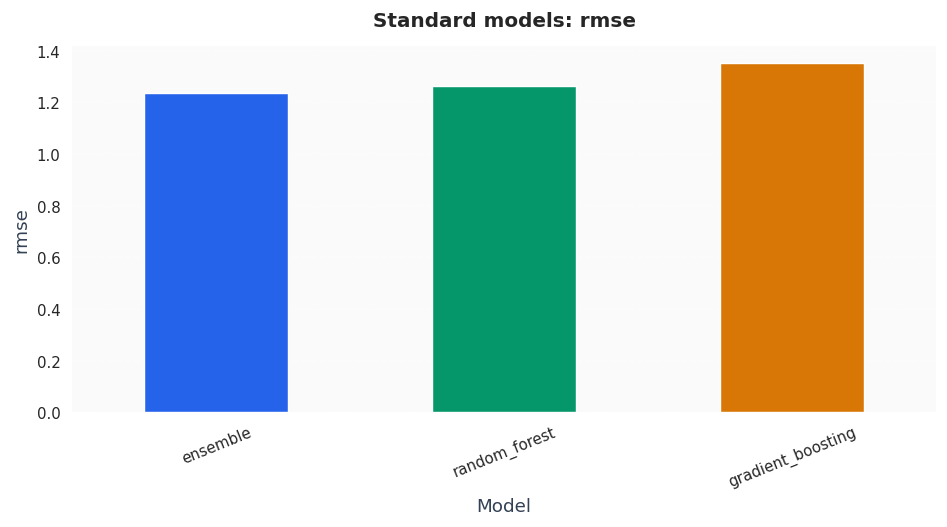

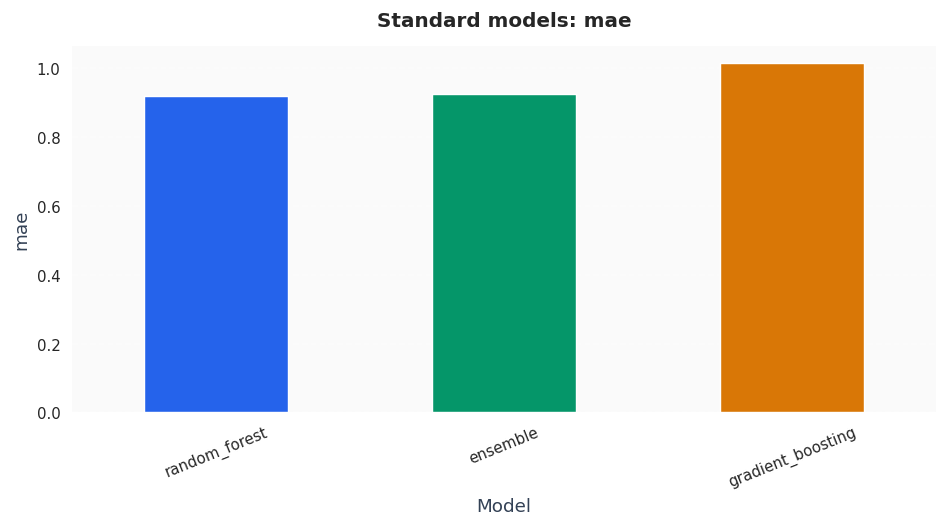

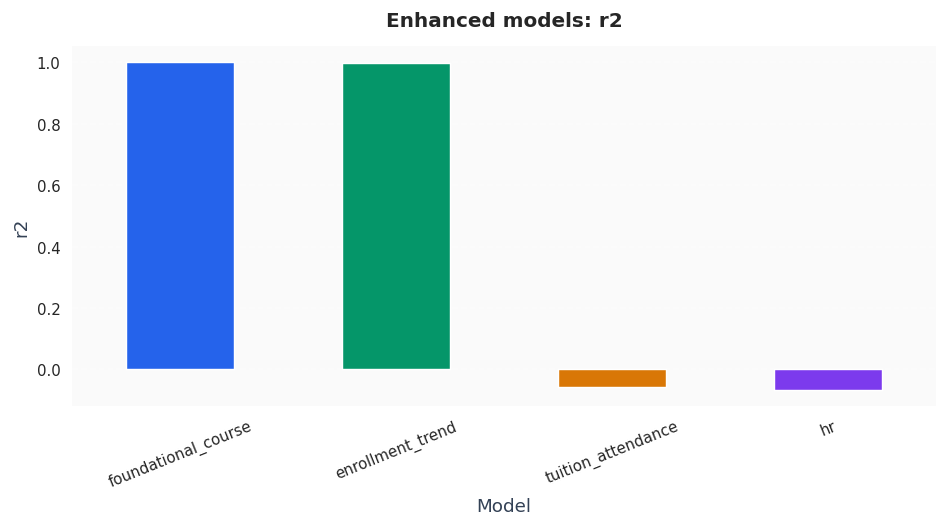

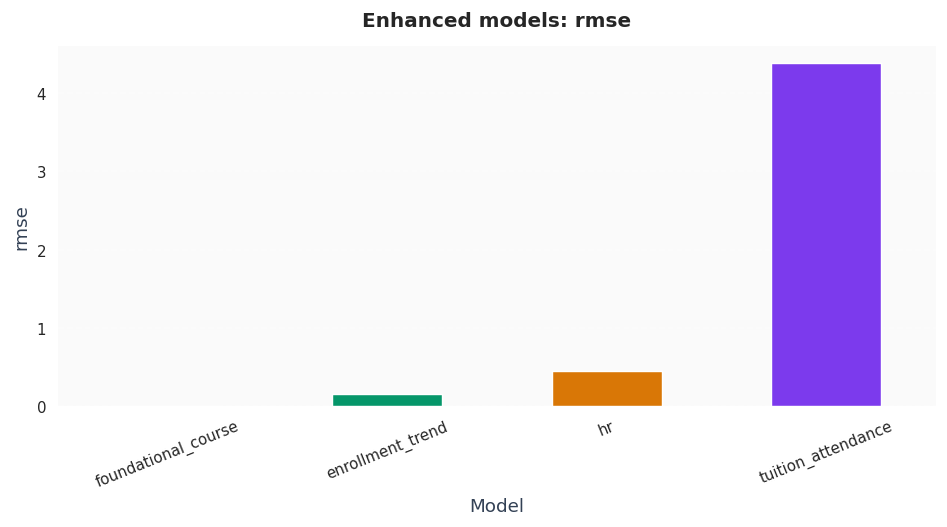

In [8]:
# Final charts (run after enhanced training)
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cbd5e1',
    'axes.labelcolor': '#334155',
    'axes.titleweight': '600',
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'sans-serif',
})

CHART_BAR_COLORS = [
    '#2563eb', '#059669', '#d97706', '#7c3aed', '#0891b2',
    '#4f46e5', '#0d9488', '#6366f1', '#ca8a04', '#0284c7',
]


def _bar_colors(n):
    return [CHART_BAR_COLORS[i % len(CHART_BAR_COLORS)] for i in range(n)]


def _finish_bar_chart(ax, title, ylabel, xlabel='Model'):
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis='x', rotation=22)
    ax.yaxis.grid(True, linestyle='--', alpha=0.35)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('#cbd5e1')
    ax.spines['left'].set_color('#cbd5e1')
    plt.tight_layout()


def _plot_sorted_bars(series, title, ylabel, ascending):
    s = series.sort_values(ascending=ascending)
    ax = s.plot(
        kind='bar',
        figsize=(8, 4.5),
        color=_bar_colors(len(s)),
        edgecolor='white',
        linewidth=0.85,
    )
    _finish_bar_chart(ax, title, ylabel)
    plt.show()


std_df = pd.DataFrame.from_dict(globals().get('standard_results', {}), orient='index')

for m in ['r2', 'rmse', 'mae']:
    if m in std_df.columns and not std_df.empty:
        _plot_sorted_bars(std_df[m], f'Standard models: {m}', m, ascending=(m != 'r2'))

rows = []
if 'enhanced_results' in globals() and isinstance(enhanced_results, dict):
    for model_name, metrics in enhanced_results.items():
        if isinstance(metrics, dict):
            for k, v in metrics.items():
                rows.append((model_name, k, v))

enh_table = pd.DataFrame(rows, columns=['model', 'metric', 'value']) if rows else pd.DataFrame(columns=['model', 'metric', 'value'])

if not enh_table.empty:
    for m in ['r2', 'rmse']:
        subset = enh_table[enh_table['metric'] == m]
        if not subset.empty:
            pivot = subset.set_index('model')['value']
            _plot_sorted_bars(pivot, f'Enhanced models: {m}', m, ascending=(m == 'rmse'))

else:
    print('No enhanced_results metrics available to chart.')


## 3. Smoke test (optional)

Loads pickles from disk and runs one prediction using a real `student_id` from the warehouse.

In [10]:
from sqlalchemy import create_engine, text
from ml_models import MultiModelPredictor
from enhanced_predictions import EnhancedPredictor
from config import DATA_WAREHOUSE_CONN_STRING

# Optional: avoids failing the whole notebook if Postgres restarts mid-run.
try:
    engine = create_engine(DATA_WAREHOUSE_CONN_STRING)
    with engine.connect() as conn:
        sid = conn.execute(text("SELECT student_id FROM dim_student LIMIT 2")).scalar()
    engine.dispose()

    p = MultiModelPredictor()
    p.load_models()
    print("student_id:", sid, "ensemble pred:", p.predict(sid, "ensemble"))

    e = EnhancedPredictor()
    if e.load_all_models() and "tuition_attendance_performance" in e.models:
        print("Enhanced tuition_attendance model loaded.")
    else:
        print("Enhanced models missing or incomplete (check training cell output above).")
except Exception as ex:
    print("Smoke test skipped:", type(ex).__name__, ex)

/usr/local/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


student_id: J23B06/001 ensemble pred: 62.75783072431661
All models loaded successfully!
Enhanced tuition_attendance model loaded.
